In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('D600 Task 3 Dataset 1 Housing Information.csv')

In [3]:
df.head()

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0


In [4]:
features = ["SquareFootage", "NumBathrooms", "BackyardSpace", "CrimeRate", 
                  "SchoolRating", "AgeOfHome", "DistanceToCityCenter", "EmploymentRate", "PropertyTaxRate",
                  "RenovationQuality", "LocalAmenities", "PreviousSalePrice"]
output = ['Price']
df[features].head()

,SquareFootage,NumBathrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,PreviousSalePrice
0,566.62,1.000000,779.42,20.56,5.62,39.46,10.08,97.29,1.84,4.93,4.44,181861.54230
1,1472.34,1.000000,656.13,15.62,5.63,40.51,7.89,93.22,0.95,4.08,5.56,50042.59757
2,550.00,1.779354,754.57,12.47,9.20,48.38,23.74,96.60,1.87,4.26,8.07,48400.34440
3,941.81,2.035254,439.59,22.22,7.08,94.67,5.22,91.45,1.45,4.45,5.00,84594.12145
4,550.00,1.064644,353.03,8.28,5.93,16.80,43.13,86.50,1.26,3.36,5.46,22934.59654


In [5]:
df[features].dtypes

SquareFootage           float64
NumBathrooms            float64
BackyardSpace           float64
CrimeRate               float64
SchoolRating            float64
AgeOfHome               float64
DistanceToCityCenter    float64
EmploymentRate          float64
PropertyTaxRate         float64
RenovationQuality       float64
LocalAmenities          float64
PreviousSalePrice       float64
dtype: object

In [6]:
df[features].describe()

,SquareFootage,NumBathrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,PreviousSalePrice
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,1048.947459,2.131397,511.507029,31.226194,6.942923,46.797046,17.475337,93.711349,1.500437,5.003357,5.934579,2.845094e+05
std,426.010482,0.952561,279.926549,18.025327,1.888148,31.779701,12.024985,4.505359,0.498591,1.970428,2.657930,1.857340e+05
min,550.000000,1.000000,0.390000,0.030000,0.220000,0.010000,0.000000,72.050000,0.010000,0.010000,0.000000,-8.356902e+03
25%,660.815000,1.290539,300.995000,17.390000,5.650000,20.755000,7.827500,90.620000,1.160000,3.660000,4.000000,1.420140e+05
50%,996.320000,1.997774,495.965000,30.385000,7.010000,42.620000,15.625000,94.010000,1.490000,5.020000,6.040000,2.621831e+05
75%,1342.292500,2.763997,704.012500,43.670000,8.360000,67.232500,25.222500,97.410000,1.840000,6.350000,8.050000,3.961212e+05
max,2874.700000,5.807239,1631.360000,99.730000,10.000000,178.680000,65.200000,99.900000,3.360000,10.000000,10.000000,1.296607e+06


In [7]:
df[features].to_csv('Cleaned D600 Task 3 Dataset 1 Housing Information.csv', index=True)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_std = scaler.fit_transform(df[features])
features_std_df = pd.DataFrame(features_std, columns=features, index=df.index)

print(features_std_df.head())

   SquareFootage  NumBathrooms  BackyardSpace  CrimeRate  SchoolRating  \
0      -1.132277     -1.187828       0.957151  -0.591776     -0.700696   
1       0.993926     -1.187828       0.516683  -0.865854     -0.695399   
2      -1.171293     -0.369602       0.868372  -1.040621      1.195478   
3      -0.251508     -0.100938      -0.256932  -0.499677      0.072604   
4      -1.171293     -1.119960      -0.566178  -1.273088     -0.536502   

   AgeOfHome  DistanceToCityCenter  EmploymentRate  PropertyTaxRate  \
0  -0.230889             -0.615042        0.794367         0.681094   
1  -0.197846             -0.797175       -0.109066        -1.104064   
2   0.049814              0.521008        0.641205         0.741268   
3   1.506508             -1.019229       -0.501960        -0.101167   
4  -0.943973              2.133599       -1.600730        -0.482268   

   RenovationQuality  LocalAmenities  PreviousSalePrice  
0          -0.037232       -0.562349          -0.552700  
1          -

In [9]:
from sklearn.decomposition import PCA
pca = PCA(n_components=12)
features_pca = pca.fit_transform(features_std_df)

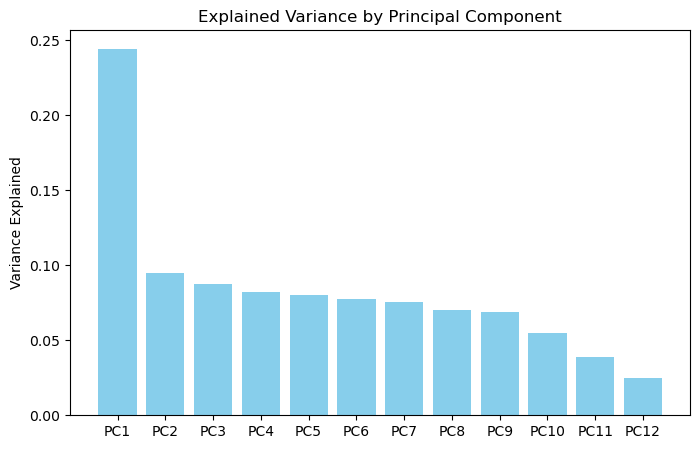

In [10]:

plt.figure(figsize=(8, 5))
plt.bar(x=[f'PC{i+1}' for i in range(12)], height=pca.explained_variance_ratio_, color='skyblue')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Principal Component')
plt.show()

In [11]:
print(pca.explained_variance_ratio_)

[0.24458752 0.09507426 0.08773864 0.08200825 0.08013062 0.07726781
 0.07525867 0.07036778 0.06910273 0.05511438 0.03862498 0.02472437]


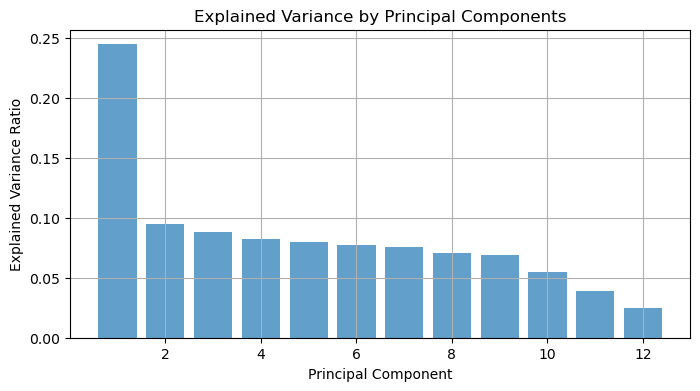

In [12]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()

In [13]:
#K-means
from sklearn.cluster import KMeans

wcss = []
for i in range(1,12):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_pca.fit(features_pca)
    wcss.append(kmeans_pca.inertia_)

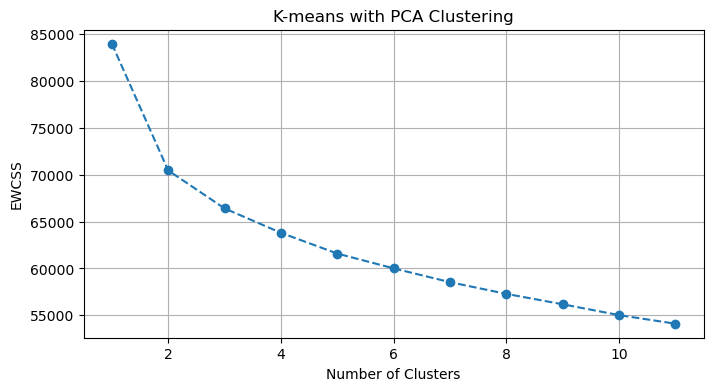

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 12), wcss, marker= 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('EWCSS')
plt.title('K-means with PCA Clustering')
plt.grid(True)
plt.show()

In [15]:
#Elbow rule = kink comes at 2 cluster mark

kmeans_pca = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
kmeans_pca.fit(features_pca)

KMeans(n_clusters=2, random_state=42)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, BayesianRidge

from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score

no display found. Using non-interactive Agg backend


In [17]:
features_pca_df2 = pd.DataFrame(features_pca)
print(features_pca_df2.head())

         0         1         2         3         4         5         6   \
0 -1.112119 -1.479381 -0.149675  0.790207  0.003981  0.725597 -0.775387   
1 -0.595805 -0.984526 -1.214523  0.422028 -0.592293  0.108573  0.845456   
2 -0.644174 -2.027531  0.667082  0.655527  0.854227  0.468915  0.156553   
3 -0.829104 -0.130610  0.161559 -0.252389 -0.696107  0.820997  0.993387   
4 -2.457277 -0.799935 -0.705497 -0.422253 -0.147008 -0.036537  1.071090   

         7         8         9         10        11  
0 -0.577320 -0.357568  0.047679  0.663781  0.704216  
1 -1.475686  0.338509 -0.427015  0.319691 -1.003117  
2  0.692669 -0.034882  0.971117 -0.722930 -0.303321  
3 -0.443000 -1.244687  0.482851  0.043180 -0.637209  
4  1.304471  2.265980  0.555674  0.354577 -0.098727  


In [18]:
features_pca_df2 = pd.DataFrame(
    features_pca,
    columns=[f"PC{i+1}" for i in range(features_pca.shape[1])],
    index=df.index
)
print(features_pca_df2.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.112119 -1.479381 -0.149675  0.790207  0.003981  0.725597 -0.775387   
1 -0.595805 -0.984526 -1.214523  0.422028 -0.592293  0.108573  0.845456   
2 -0.644174 -2.027531  0.667082  0.655527  0.854227  0.468915  0.156553   
3 -0.829104 -0.130610  0.161559 -0.252389 -0.696107  0.820997  0.993387   
4 -2.457277 -0.799935 -0.705497 -0.422253 -0.147008 -0.036537  1.071090   

        PC8       PC9      PC10      PC11      PC12  
0 -0.577320 -0.357568  0.047679  0.663781  0.704216  
1 -1.475686  0.338509 -0.427015  0.319691 -1.003117  
2  0.692669 -0.034882  0.971117 -0.722930 -0.303321  
3 -0.443000 -1.244687  0.482851  0.043180 -0.637209  
4  1.304471  2.265980  0.555674  0.354577 -0.098727  


In [19]:
features_pca_df3 = features_pca_df2.rename(columns={
    "PC1": "SquareFootage1",
    "PC2": "NumBathrooms2"
})

In [20]:
X = features_pca_df3[["SquareFootage1", "NumBathrooms2"]]

y = df[output]['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [21]:
train_data = pd.concat([y_train, X_train], axis=1)
test_data = pd.concat([y_test, X_test], axis=1)

train_data.to_csv('X_train.csv', index=False)
test_data.to_csv('X_test.csv', index=False)

In [22]:
lreg = LinearRegression()
lreg.fit(X_train, y_train)

LinearRegression()

In [23]:
print(pd.DataFrame({'features': X.columns, 'coefficient': lreg.coef_}))
regressionSummary(y_train, lreg.predict(X_train))

         features   coefficient
0  SquareFootage1  64298.083370
1   NumBathrooms2  35286.125181

Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 94696.7110
            Mean Absolute Error (MAE) : 74199.2891
          Mean Percentage Error (MPE) : -9.0331
Mean Absolute Percentage Error (MAPE) : 27.0948


In [24]:
def train_model(variables):
    model = LinearRegression()
    model.fit(X_train[variables], y_train)
    return model

def score_model(model, variables):
    return AIC_score(y_train, model.predict(X_train[variables]), model)
    
allVariables = list(X_train.columns)

best_model, best_variables = backward_elimination(allVariables, train_model, score_model, verbose=True)

print(best_variables)

regressionSummary(y_test, best_model.predict(X_test[best_variables]))

Variables: SquareFootage1, NumBathrooms2
Start: score=108177.93
Step: score=108177.93, remove None
['SquareFootage1', 'NumBathrooms2']

Regression statistics

                      Mean Error (ME) : -2669.9696
       Root Mean Squared Error (RMSE) : 94735.5295
            Mean Absolute Error (MAE) : 74443.1529
          Mean Percentage Error (MPE) : -10.4721
Mean Absolute Percentage Error (MAPE) : 28.0092


In [25]:
import statsmodels.formula.api as smf 

train_df = X_train.join(y_train)

Feature = X_train.columns
formula = 'Price ~ ' + ' + '.join([str(f) for f in Feature])  # Convert each feature to string

Feature_lm = smf.ols(formula=formula, data=train_df).fit()
Feature_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     3201.
Date:                Sat, 16 Aug 2025   Prob (F-statistic):               0.00
Time:                        04:15:18   Log-Likelihood:                -54085.
No. Observations:                4200   AIC:                         1.082e+05
Df Residuals:                    4197   BIC:                         1.082e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       3.083e+05   1461.813    210.937      0.000    3.05e+05    3.11e+05
SquareFootage1   6.43e+04    844.342     76.152      0.000    6.26e+04     6.6e+04
NumBathrooms2   3.529e+04   1379.481     25.579      0.000    3.26e+04     3.8e+04
==============================================================================
Omnibus:                      245.320   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              303.682
Skew:                           0.576   Prob(JB):                     1.14e-66
Kurtosis:                       3.639   Cond. No.                         1.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
features_lm_pred = lreg.predict(X_test)

result = pd.DataFrame({'Predicted': features_lm_pred, 'Actual': y_test,
                       'Residual': y_test - features_lm_pred})
print(result.head(20))

regressionSummary(y_test, features_lm_pred)

          Predicted       Actual       Residual
6500  370489.125325  588317.6568  217828.531475
2944  173144.228497  104021.6679  -69122.560597
2024  250820.605177  185708.2598  -65112.345377
263   148399.051142  128945.4664  -19453.584742
4350  486548.148273  343116.7513 -143431.396973
3424  165523.258970  190134.3678   24611.108830
6748  626079.895409  741922.7803  115842.884891
6215  311762.994125  300770.4502  -10992.543925
6362  344454.459971  289653.3039  -54801.156071
5589  282832.077890  315696.8350   32864.757110
132   212272.075091  256224.6335   43952.558409
6406  309488.901542  389635.1346   80146.233058
4279  362591.689590  538054.4792  175462.789610
2398  256013.516124  231352.1189  -24661.397224
5712  481225.700212  313705.9364 -167519.763812
3254  130931.397712  178537.8948   47606.497088
6026  391986.442518  316276.3761  -75710.066418
2264  286109.875871  194376.8764  -91732.999471
1941  122917.059470  108413.2684  -14503.791070
763   226685.009011  201297.8057  -25387

In [27]:
best_model, best_variables = stepwise_selection(
    list(X_train.columns),
    train_model,
    score_model,
    direction='backward', 
    verbose=True
)
print(best_variables)

Variables: SquareFootage1, NumBathrooms2
Start: score=108177.93, constant
Step: score=108177.93, unchanged None
['SquareFootage1', 'NumBathrooms2']


In [28]:
 import statsmodels.api as sm
X_train_const = sm.add_constant(X_train[best_variables])
ols_model = sm.OLS(y_train, X_train_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     3201.
Date:                Sat, 16 Aug 2025   Prob (F-statistic):               0.00
Time:                        04:15:20   Log-Likelihood:                -54085.
No. Observations:                4200   AIC:                         1.082e+05
Df Residuals:                    4197   BIC:                         1.082e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.083e+05   1461.813    210.

In [29]:
from sklearn.metrics import mean_squared_error

y_train_pred = ols_model.predict(X_train_const)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Training MSE: {mse_train}")

Training MSE: 8967467078.133615


In [30]:
X_test_const = sm.add_constant(X_test[best_variables])
y_test_pred = ols_model.predict(X_test_const)

mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test}")

Test MSE: 8974820542.425623
